In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_csv('Mall_Customers.csv')

In [4]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
X = dataset.iloc[:, [3,4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [7]:
from sklearn.cluster import OPTICS
OP=OPTICS(min_samples=5).fit(X)
y_OP=OP.fit_predict(X)
n_clusters = len(set(y_OP)) - (1 if -1 in y_OP else 0)
print("Estimated number of clusters:", n_clusters)

Estimated number of clusters: 11


In [8]:
n_noise = list(y_OP).count(-1)
print("Noise points:", n_noise)

Noise points: 80


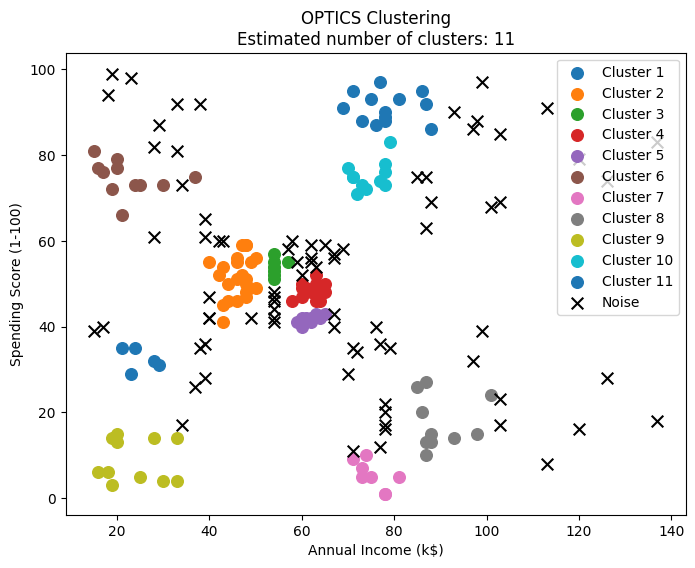

In [9]:
# Number of clusters (excluding noise)
n_clusters = len(set(y_OP)) - (1 if -1 in y_OP else 0)

plt.figure(figsize=(8,6))

# Plot each cluster
for i in set(y_OP):
    if i == -1:
        # Noise points
        plt.scatter(X[y_OP == i, 0],
                    X[y_OP == i, 1],
                    c='black',
                    marker='x',
                    s=70,
                    label='Noise')
    else:
        plt.scatter(X[y_OP == i, 0],
                    X[y_OP == i, 1],
                    s=70,
                    label=f'Cluster {i+1}')

plt.title(f"OPTICS Clustering\nEstimated number of clusters: {n_clusters}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [10]:
from sklearn.cluster import OPTICS
OP=OPTICS(min_samples=5).fit(X)
y_OP=OP.fit_predict(X)

In [11]:
supervised = pd.DataFrame(dataset)

In [12]:
supervised['cluster_group']=y_OP
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,5
2,3,Female,20,16,6,8
3,4,Female,23,16,77,5
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


E:\anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


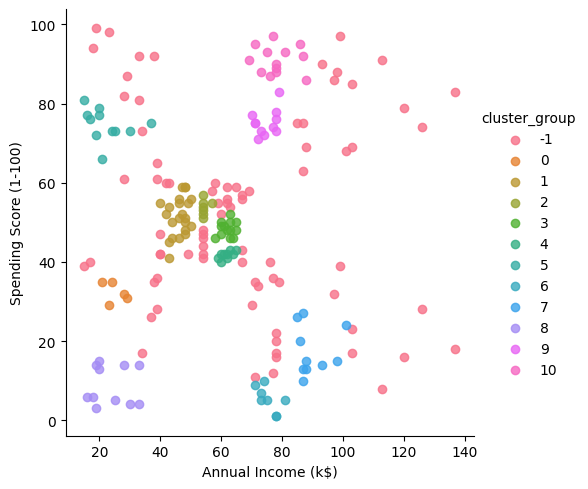

In [13]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3],
y=supervised.columns[4], hue=supervised.columns[5],
 fit_reg=False, legend=True, legend_out=True)